# IMPORT LIBRARIES

In [1]:
import sys
!{sys.executable} -m pip install pandas matplotlib ipywidgets -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

from IPython.display import display, clear_output
import ipywidgets as widgets

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline 

# IMPORT DATASET

In [3]:
df = pd.read_excel("Credit Risk Dataset.xlsx")

In [4]:
df.head()

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,...,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,...,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,...,42.8864,-78.8784,Part-time,36,0.643382,15626.153439,0.930628,4,0.228103,0


In [5]:
df.tail()

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
32576,CUST_32577,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,...,49.2827,-123.1207,Part-time,36,0.109434,15721.464516,0.406065,11,0.892039,1
32577,CUST_32578,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,...,53.4808,-2.2426,Full-time,60,0.146875,29674.399348,0.394162,6,0.191486,0
32578,CUST_32579,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,...,53.4808,-2.2426,Unemployed,24,0.460526,21098.865051,0.738143,11,0.678980,3
32579,CUST_32580,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,...,37.7749,-122.4194,Self-employed,36,0.100000,26361.525753,0.275744,3,0.223460,1
32580,CUST_32581,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,...,46.8139,-71.2080,Full-time,60,0.154167,9397.997205,0.377929,4,0.429304,1


In [6]:
print(f"Number of columns: {len(df.columns)}")

Number of columns: 29


In [7]:
df.shape

(32581, 29)

In [8]:
df.nunique()

client_ID                     32581
person_age                       58
person_income                  4295
person_home_ownership             4
person_emp_length                36
loan_intent                       6
loan_grade                        7
loan_amnt                       753
loan_int_rate                   348
loan_status                       2
loan_percent_income              77
cb_person_default_on_file         2
cb_person_cred_hist_length       29
gender                            2
marital_status                    4
education_level                   4
country                           3
state                             9
city                             18
city_latitude                    18
city_longitude                   18
employment_type                   4
loan_term_months                  4
loan_to_income_ratio           9914
other_debt                    32581
debt_to_income_ratio          32581
open_accounts                    16
credit_utilization_ratio    

In [9]:
df.dtypes

client_ID                      object
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
gender                         object
marital_status                 object
education_level                object
country                        object
state                          object
city                           object
city_latitude                 float64
city_longitude                float64
employment_type                object
loan_term_months                int64
loan_to_income_ratio          float64
other_debt                    float64
debt_to_income_ratio          float64
open_account

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  object 
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  object 
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  object 
 6   loan_grade                  32581 non-null  object 
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  object 
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender                      325

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.000000,23.000000,26.000000,30.000000,1.440000e+02
person_income,32581.0,66074.848470,61983.119168,4000.000000,38500.000000,55000.000000,79200.000000,6.000000e+06
person_emp_length,31686.0,4.789686,4.142630,0.000000,2.000000,4.000000,7.000000,1.230000e+02
loan_amnt,32581.0,9589.371106,6322.086646,500.000000,5000.000000,8000.000000,12200.000000,3.500000e+04
loan_int_rate,29465.0,11.011695,3.240459,5.420000,7.900000,10.990000,13.470000,2.322000e+01
loan_status,32581.0,0.218164,0.413006,0.000000,0.000000,0.000000,0.000000,1.000000e+00
loan_percent_income,32581.0,0.170203,0.106782,0.000000,0.090000,0.150000,0.230000,8.300000e-01
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.000000,3.000000,4.000000,8.000000,3.000000e+01
city_latitude,32581.0,45.407613,7.644809,29.760400,40.712800,46.813900,51.507400,5.595330e+01
city_longitude,32581.0,-63.805473,46.615580,-123.365600,-96.797000,-75.697200,-3.943600,-1.278000e-01


In [12]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

loan_int_rate        9.563856
person_emp_length    2.747000
dtype: float64


In [13]:
df.columns[df.isnull().any()] #checking columns that null

Index(['person_emp_length', 'loan_int_rate'], dtype='object')

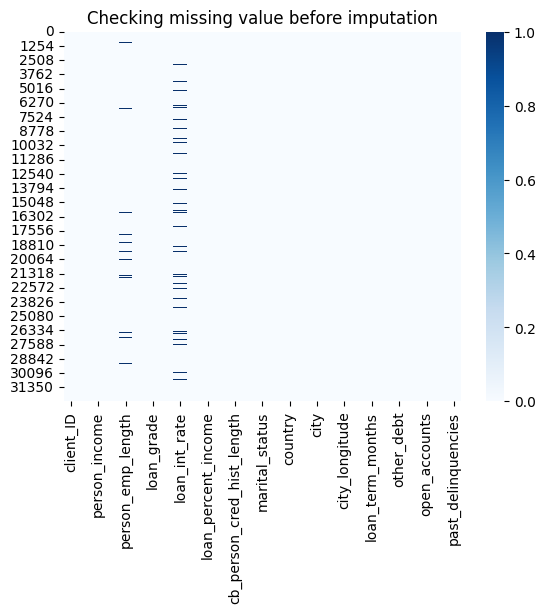

In [14]:
sns.heatmap(df.isnull(), cmap ="Blues")
plt.title("Checking missing value before imputation")
plt.show()

#### Checking abnormal values

In [15]:
df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'] \
                        .transform(lambda x: x.fillna(x.median()))

# 1) person_age > 100 is unrealistic -> set to NaN
if 'person_age' in df.columns:
    df.loc[df['person_age'] > 100, 'person_age'] = np.nan

# 2) person_emp_length invalid (e.g., 123) or > person_age -> set to NaN
if 'person_emp_length' in df.columns:
    df.loc[df['person_emp_length'] < 0, 'person_emp_length'] = np.nan

    if 'person_age' in df.columns:
        df.loc[df['person_emp_length'] > df['person_age'], 'person_emp_length'] = np.nan


# (keep current approach; now it will also fill NaNs introduced above)
if 'person_age' in df.columns:
    df['person_age'] = df['person_age'].fillna(df['person_age'].median())

df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

print(df.isnull().sum().sum())

0


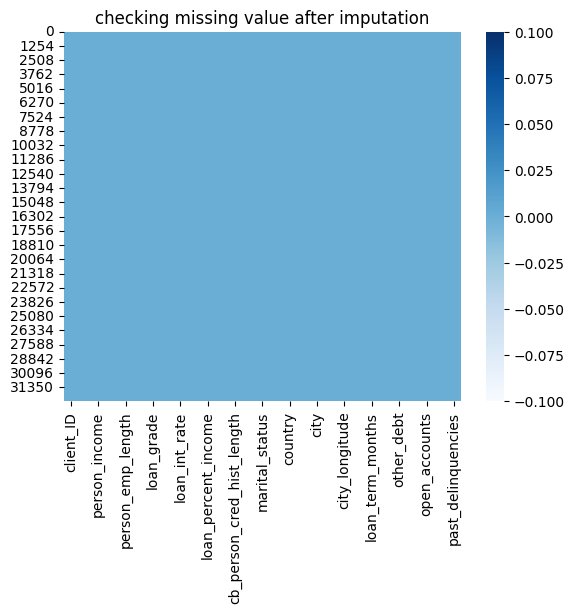

In [16]:
sns.heatmap(df.isnull(), cmap ="Blues")
plt.title("checking missing value after imputation")
plt.show()

In [17]:
for col in df.columns:
    missing_data = df[col].isna().sum()
    missing_per = missing_data /len(df)*100
    print(f"Column {col} has {missing_per}% missing data")

Column client_ID has 0.0% missing data
Column person_age has 0.0% missing data
Column person_income has 0.0% missing data
Column person_home_ownership has 0.0% missing data
Column person_emp_length has 0.0% missing data
Column loan_intent has 0.0% missing data
Column loan_grade has 0.0% missing data
Column loan_amnt has 0.0% missing data
Column loan_int_rate has 0.0% missing data
Column loan_status has 0.0% missing data
Column loan_percent_income has 0.0% missing data
Column cb_person_default_on_file has 0.0% missing data
Column cb_person_cred_hist_length has 0.0% missing data
Column gender has 0.0% missing data
Column marital_status has 0.0% missing data
Column education_level has 0.0% missing data
Column country has 0.0% missing data
Column state has 0.0% missing data
Column city has 0.0% missing data
Column city_latitude has 0.0% missing data
Column city_longitude has 0.0% missing data
Column employment_type has 0.0% missing data
Column loan_term_months has 0.0% missing data
Column 

In [18]:
print("Categorical columns:")
print(df.select_dtypes(include='object').columns.tolist())

Categorical columns:
['client_ID', 'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'gender', 'marital_status', 'education_level', 'country', 'state', 'city', 'employment_type']


In [19]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
32576    False
32577    False
32578    False
32579    False
32580    False
Length: 32581, dtype: bool

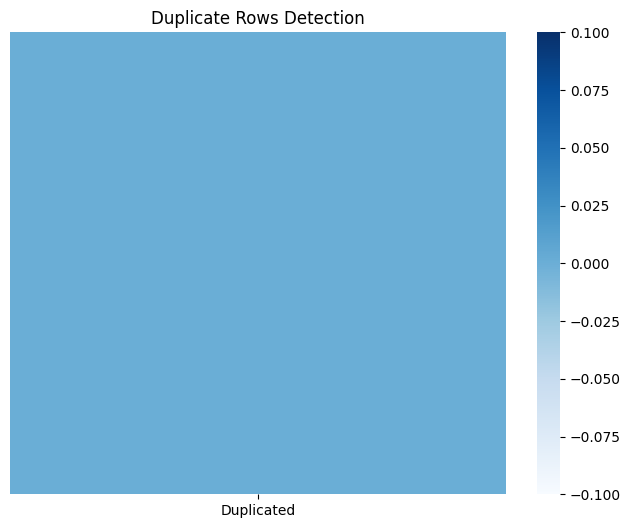

In [20]:
duplicated_df = pd.DataFrame(df.duplicated(keep=False), columns=['Duplicated'])
plt.figure(figsize=(8, 6))
sns.heatmap(duplicated_df.astype(int), cbar=True, cmap='Blues', yticklabels=False)
plt.title('Duplicate Rows Detection')
plt.show()

In [21]:
df.to_csv('dataset_cleaned.csv', index=False)

In [22]:
numeric_values = pd.to_numeric(df[col], errors='coerce')
non_numeric_count = numeric_values.isna().sum() - df[col].isna().sum()

In [23]:
print("1. WHITESPACE & EMPTY VALUES") 
for col in df.select_dtypes(include='object').columns:
    # Leading/trailing spaces
    spaces = df[col].astype(str).str.match(r'^\s|\s$').sum()
    if spaces > 0:
        print(f"{col}: {spaces} values with spaces")
    
    # Empty strings
    empty = (df[col].astype(str).str.strip() == '').sum()
    if empty > 0:
        print(f"{col}: {empty} empty values")
 

print("2. DATA TYPES")
print(df.dtypes)
for col in df.select_dtypes(include='object').columns:
    non_numeric = pd.to_numeric(df[col], errors='coerce').isna().sum() - df[col].isna().sum()
    if non_numeric > 0:
        print(f" {col}: {non_numeric} non-numeric values")
 

print("3. VALUE RANGES (Numerical)")
for col in df.select_dtypes(include=[np.number]).columns:
    print(f"\n{col}:")
    print(f"  Min: {df[col].min():.2f}, Max: {df[col].max():.2f}")
    
    if (df[col] < 0).sum() > 0:
        print(f" {(df[col] < 0).sum()} negative values")
    
    if (df[col] == 0).sum() > 0:
        print(f"  Zero values: {(df[col] == 0).sum()}")
 

print("4. CATEGORICAL VALUES")
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(f"  Top 5: {df[col].value_counts().head(5).to_dict()}")
    
    rare = (df[col].value_counts() < len(df) * 0.01).sum()
    if rare > 0:
        print(f"{rare} rare values (< 1%)")
 

print("5. CASE INCONSISTENCIES")
for col in df.select_dtypes(include='object').columns:
    unique_vals = df[col].dropna().unique()
    
    val_lower = {}
    for v in unique_vals:
        key = str(v).lower()
        if key not in val_lower:
            val_lower[key] = []
        val_lower[key].append(v)
    
    case_issues = {k: v for k, v in val_lower.items() if len(v) > 1}
    if case_issues:
        print(f"\n{col}: Case inconsistencies found:")
        for variants in list(case_issues.values())[:3]:
            print(f"  {variants}")

1. WHITESPACE & EMPTY VALUES
2. DATA TYPES
client_ID                      object
person_age                    float64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
gender                         object
marital_status                 object
education_level                object
country                        object
state                          object
city                           object
city_latitude                 float64
city_longitude                float64
employment_type                object
loan_term_months                int64
loan_to_income_ratio          float64
other_debt                    float64
debt_to

In [24]:
# Outlier check only for truly continuous-ish numeric features.
# Skip target and any binary / encoded columns (<=2 unique values).
TARGET_COL = 'loan_status'

for col in df.select_dtypes(include=[np.number]).columns:
    if col == TARGET_COL:
        continue

    nunique = df[col].dropna().nunique()
    if nunique <= 2:
        continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    if IQR == 0 or pd.isna(IQR):
        continue

    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]

    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers ({(len(outliers)/len(df)*100):.2f}%)")

person_age: 1489 outliers (4.57%)
person_income: 1484 outliers (4.55%)
person_emp_length: 851 outliers (2.61%)
loan_amnt: 1689 outliers (5.18%)
loan_int_rate: 6 outliers (0.02%)
loan_percent_income: 651 outliers (2.00%)
cb_person_cred_hist_length: 1142 outliers (3.51%)
loan_to_income_ratio: 733 outliers (2.25%)
other_debt: 1559 outliers (4.78%)
debt_to_income_ratio: 463 outliers (1.42%)
past_delinquencies: 464 outliers (1.42%)


In [25]:
print("VARIABLE CLASSIFICATION")

DROP_COLS = ['client_ID', 'state', 'city', 'city_latitude', 'city_longitude']

# Numerical continuous variables (measured on a scale)
NUM_CONT_VARS = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'cb_person_cred_hist_length',
    'loan_term_months',
    'other_debt'
]

# Numerical discrete / count variables
NUM_COUNT_VARS = [
    'open_accounts',
    'past_delinquencies'
]

# Derived features (computed ratios/transformations)
DERIVED_VARS = [
    'loan_percent_income',
    'loan_to_income_ratio',
    'debt_to_income_ratio',
    'credit_utilization_ratio'
]

# Convenience combined list used later
NUMERICAL_VARS = NUM_CONT_VARS + NUM_COUNT_VARS

ORDINAL_VARS = ['loan_grade', 'education_level']

BINARY_VARS = ['cb_person_default_on_file', 'gender']

NOMINAL_VARS = [
    'person_home_ownership', 'loan_intent',
    'marital_status', 'country', 'employment_type'
]

TARGET = 'loan_status'

print(f"\nNumerical-Continuous ({len(NUM_CONT_VARS)}):  {NUM_CONT_VARS}")
print(f"Numerical-Count      ({len(NUM_COUNT_VARS)}):  {NUM_COUNT_VARS}")
print(f"Derived              ({len(DERIVED_VARS)}):  {DERIVED_VARS}")
print(f"Ordinal              ({len(ORDINAL_VARS)}):  {ORDINAL_VARS}")
print(f"Binary               ({len(BINARY_VARS)}):  {BINARY_VARS}")
print(f"Nominal              ({len(NOMINAL_VARS)}):  {NOMINAL_VARS}")
print(f"Target               : {TARGET}")
print(f"Dropped              : {DROP_COLS}")

# --- Task 2: variable classification table (report-ready) ---
TASK2_ENGINEERED_FEATURES = [
    "severe_default_history",
    "vulnerable_borrower",
    "monthly_payment_to_income",
]

def _cred_row(variable, main_type, sub_type, meaning, treatment):
    return {
        "Variable": variable,
        "Main Type": main_type,
        "Sub-Type": sub_type,
        "Credit Risk Meaning": meaning,
        "Suggested Treatment": treatment,
    }

def classify_column(v):
    if v == TARGET:
        return _cred_row(v, "Target", "Binary (0/1)", "Historical default outcome for supervised modelling",
                         "Exclude from features; stratify splits; never treat as continuous outlier check")
    if v in DROP_COLS:
        return _cred_row(v, "Dropped", "Identifier / geo", "Not used as predictive inputs in our pipeline",
                         "Drop before modelling (`DROP_COLS`)")
    if v in NUM_CONT_VARS:
        return _cred_row(v, "Numerical", "Continuous", "Raw scale measure of affordability, capacity or loan economics",
                         "Retain; skewed amounts may use log1p; scale in preprocessing")
    if v in NUM_COUNT_VARS:
        if v == "open_accounts":
            mn = "Count of credit lines — exposure breadth"
        else:
            mn = "Historical delinquency count — repayment stress indicator"
        return _cred_row(v, "Numerical", "Discrete / count", mn,
                         "Keep as nonnegative counts; Winsor rare extremes if justified")
    if v in DERIVED_VARS:
        m = {
            "loan_percent_income": ("Installment burden relative to nominal income proxy", ""),
            "loan_to_income_ratio": ("loan_amnt divided by income — leverage / debt capacity constraint", ""),
            "debt_to_income_ratio": ("Aggregate debt servicing pressure vs income — core affordability signal", ""),
            "credit_utilization_ratio": ("Delinquencies vs open accounts proxy — revolving stress / misuse", ""),
        }.get(v, ("Ratio engineered from primitives", ""))[0]
        return _cred_row(v, "Derived", "Ratio / transformed", m,
                         "Retain as numeric ratio; Winsor outliers; interpret monotonic lift with PD")
    if v in ORDINAL_VARS:
        return _cred_row(v, "Categorical", "Ordinal ordered", "Monotonic ordinal credit / education ladders",
                         "Ordinal integer mapping preserves order → then scale with other numerics")
    if v in BINARY_VARS:
        return _cred_row(v, "Categorical", "Binary", "Discrete borrower attributes influencing risk",
                         "Map to {0,1}; no one-hot explosion")
    if v in NOMINAL_VARS:
        return _cred_row(v, "Categorical", "Nominal", "Non-ordered segments (segmentation / structure effects)",
                         "One-hot encoding with `drop_first=True` to avoid dummy trap")
    return _cred_row(v, "Other", "Unclassified", "Review domain definition", "Manual review")

var_class_rows = [classify_column(c) for c in df.columns]
for name in TASK2_ENGINEERED_FEATURES:
    if name == "severe_default_history":
        var_class_rows.append(_cred_row(
            name, "Derived", "Binary flag (0/1)",
            "Prior delinquency count > 0 OR flag Y on credit-bureau default field",
            "Include in model as 0/1; interpret as structural risk driver"))
    elif name == "vulnerable_borrower":
        var_class_rows.append(_cred_row(
            name, "Derived", "Binary flag (0/1)",
            "High debt-to-income renter — stacked affordability + housing tenure stress",
            "Include in model as 0/1; monitor segment default rates"))
    else:
        var_class_rows.append(_cred_row(
            name, "Derived", "Continuous ratio",
            "Estimated monthly payment vs monthly income — cashflow sufficiency",
            "Include; quartile default-rate stress test; scale in modelling"))

variable_classification_df = (
    pd.DataFrame(var_class_rows)
    .drop_duplicates(subset=["Variable"], keep="last")
    .sort_values("Variable")
    .reset_index(drop=True)
)
display(variable_classification_df)
variable_classification_df.to_csv("task2_variable_classification.csv", index=False)
print("Saved: task2_variable_classification.csv")

# --- Task 2: encoding / transformation strategy table ---
LOG_COLS_PLAN = ["person_income", "loan_amnt", "other_debt"]

def encoding_strategy_for(v):
    if v == TARGET:
        return v, "None (target)", "Label only — not encoded as a feature column"
    if v in DROP_COLS:
        return v, "Dropped", "Removed before modelling to avoid noise / dimensionality"
    if v in LOG_COLS_PLAN:
        return v, "Log1p + scaling", "Heavy-tailed amounts; log1p stabilizes variance then StandardScaler in train split"
    if v in ORDINAL_VARS:
        return v, "Ordinal mapping + scaling", "Preserves order (grade / education ladder); map to integers"
    if v in BINARY_VARS:
        return v, "Binary mapping", "Two-level categories → {0,1}"
    if v in NOMINAL_VARS:
        return v, "One-hot (drop_first)", "Nominal categories; drop_first avoids full-rank collinearity"
    if v in NUM_CONT_VARS and v not in LOG_COLS_PLAN:
        return v, "Scaling (StandardScaler)", "Continuous features scaled using train statistics only"
    if v in NUM_COUNT_VARS:
        return v, "Scaling (StandardScaler)", "Count features treated as numeric; scale for linear models"
    if v in DERIVED_VARS:
        return v, "Scaling (StandardScaler)", "Ratios can be skewed; scaling improves linear separability"
    return v, "As-is numeric", "Already numeric in source extract"

enc_rows = [encoding_strategy_for(c) for c in df.columns]
for name in TASK2_ENGINEERED_FEATURES:
    enc_rows.append((name, "Scaling (StandardScaler)", "Engineered numeric / binary — included after FE step; scale with other numerics"))

encoding_strategy_df = (
    pd.DataFrame(enc_rows, columns=["Variable", "Encoding / transformation", "Reason (brief)"])
    .drop_duplicates(subset=["Variable"], keep="last")
    .sort_values("Variable")
    .reset_index(drop=True)
)
display(encoding_strategy_df)
encoding_strategy_df.to_csv("task2_encoding_strategy.csv", index=False)
print("Saved: task2_encoding_strategy.csv")

VARIABLE CLASSIFICATION

Numerical-Continuous (8):  ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'cb_person_cred_hist_length', 'loan_term_months', 'other_debt']
Numerical-Count      (2):  ['open_accounts', 'past_delinquencies']
Derived              (4):  ['loan_percent_income', 'loan_to_income_ratio', 'debt_to_income_ratio', 'credit_utilization_ratio']
Ordinal              (2):  ['loan_grade', 'education_level']
Binary               (2):  ['cb_person_default_on_file', 'gender']
Nominal              (5):  ['person_home_ownership', 'loan_intent', 'marital_status', 'country', 'employment_type']
Target               : loan_status
Dropped              : ['client_ID', 'state', 'city', 'city_latitude', 'city_longitude']


,Variable,Main Type,Sub-Type,Credit Risk Meaning,Suggested Treatment
0,cb_person_cred_hist_length,Numerical,Continuous,"Raw scale measure of affordability, capacity o...",Retain; skewed amounts may use log1p; scale in...
1,cb_person_default_on_file,Categorical,Binary,Discrete borrower attributes influencing risk,"Map to {0,1}; no one-hot explosion"
2,city,Dropped,Identifier / geo,Not used as predictive inputs in our pipeline,Drop before modelling (`DROP_COLS`)
3,city_latitude,Dropped,Identifier / geo,Not used as predictive inputs in our pipeline,Drop before modelling (`DROP_COLS`)
4,city_longitude,Dropped,Identifier / geo,Not used as predictive inputs in our pipeline,Drop before modelling (`DROP_COLS`)
5,client_ID,Dropped,Identifier / geo,Not used as predictive inputs in our pipeline,Drop before modelling (`DROP_COLS`)
6,country,Categorical,Nominal,Non-ordered segments (segmentation / structure...,One-hot encoding with `drop_first=True` to avo...
7,credit_utilization_ratio,Derived,Ratio / transformed,Delinquencies vs open accounts proxy — revolvi...,Retain as numeric ratio; Winsor outliers; inte...
8,debt_to_income_ratio,Derived,Ratio / transformed,Aggregate debt servicing pressure vs income — ...,Retain as numeric ratio; Winsor outliers; inte...
9,education_level,Categorical,Ordinal ordered,Monotonic ordinal credit / education ladders,Ordinal integer mapping preserves order → then...


Saved: task2_variable_classification.csv


,Variable,Encoding / transformation,Reason (brief)
0,cb_person_cred_hist_length,Scaling (StandardScaler),Continuous features scaled using train statist...
1,cb_person_default_on_file,Binary mapping,"Two-level categories → {0,1}"
2,city,Dropped,Removed before modelling to avoid noise / dime...
3,city_latitude,Dropped,Removed before modelling to avoid noise / dime...
4,city_longitude,Dropped,Removed before modelling to avoid noise / dime...
5,client_ID,Dropped,Removed before modelling to avoid noise / dime...
6,country,One-hot (drop_first),Nominal categories; drop_first avoids full-ran...
7,credit_utilization_ratio,Scaling (StandardScaler),Ratios can be skewed; scaling improves linear ...
8,debt_to_income_ratio,Scaling (StandardScaler),Ratios can be skewed; scaling improves linear ...
9,education_level,Ordinal mapping + scaling,Preserves order (grade / education ladder); ma...


Saved: task2_encoding_strategy.csv


# DATA VISUALIZATION

In [26]:
df_viz = df.copy()

BLUE, RED, NAVY = '#2196F3', '#EF5350', '#0D47A1'
GREEN, ORANGE = '#4CAF50', '#FF9800'

ALL_CAT = [
    'person_home_ownership','loan_intent','loan_grade',
    'gender','marital_status','education_level',
    'country','employment_type','cb_person_default_on_file'
]

ALL_NUM = [
    'person_age','person_income','person_emp_length',
    'loan_amnt','loan_int_rate','loan_percent_income',
    'cb_person_cred_hist_length','loan_term_months',
    'loan_to_income_ratio','debt_to_income_ratio',
    'other_debt','credit_utilization_ratio',
    'open_accounts','past_delinquencies'
]

cat_options = [c for c in ALL_CAT if c in df_viz.columns]
num_options = [c for c in ALL_NUM if c in df_viz.columns]


out6 = widgets.Output()

def plot_w6():
    with out6:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Boxplot - All Numerical Columns', fontsize=14, fontweight='bold')
        
        # All columns boxplot
        df_viz[num_options].boxplot(ax=axes[0], vert=False)
        axes[0].set_title('All Variables')
        axes[0].set_xlabel('Value')
        
        # By default status
        data_to_plot = [df_viz[df_viz['loan_status']==0][num_options[0]].dropna(),
                        df_viz[df_viz['loan_status']==1][num_options[0]].dropna()]
        bp = axes[1].boxplot(data_to_plot, labels=['Non-Default', 'Default'], patch_artist=True)
        bp['boxes'][0].set_facecolor(BLUE)
        bp['boxes'][1].set_facecolor(RED)
        axes[1].set_title(f'{num_options[0]} by Default Status')
        axes[1].set_ylabel('Value')
        
        plt.tight_layout()
        plt.show()
 
widgets.interactive_output(plot_w6, {})
display(widgets.VBox([
    widgets.HTML('<h3 style="color:#0D47A1">Checking Outliers Boxplot</h3>'),
    out6
]))
 
 
# WIDGET 7 - Correlation Heatmap
 
corr_cols_dd = widgets.SelectMultiple(
    options=num_options,
    value=num_options[:5] if len(num_options) >= 5 else num_options,
    description='Variables:',
    rows=10
)
out7 = widgets.Output()
 
def plot_w7(cols):
    with out7:
        clear_output(wait=True)
        if len(cols) < 2:
            print("Select at least 2 columns!")
            return
        
        corr_matrix = df_viz[list(cols)].corr()
        
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                    square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
        ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
 
widgets.interactive_output(plot_w7, {'cols': corr_cols_dd})
display(widgets.VBox([
    widgets.HTML('<h3 style="color:#0D47A1">Correlation Heatmap</h3>'),
    corr_cols_dd, out7
]))
 

# WIDGET 8 - Class Distribution (Target Variable)
out8 = widgets.Output()
 
def plot_w8():
    with out8:
        clear_output(wait=True)
        if 'loan_status' not in df_viz.columns:
            print("Target column 'loan_status' not found!")
            return
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Target Variable Distribution - loan_status', fontsize=14, fontweight='bold')
        
        # Count plot
        class_dist = df_viz['loan_status'].value_counts()
        class_labels = ['Non-Default', 'Default']
        
        bars = axes[0].bar(class_labels, class_dist.values, color=[BLUE, RED], edgecolor='white', width=0.5)
        axes[0].set_title('Class Distribution (Count)')
        axes[0].set_ylabel('Count')
        for b, v in zip(bars, class_dist.values):
            axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+50,
                         f'{v}\n{v/len(df_viz)*100:.1f}%', ha='center', fontsize=11, fontweight='bold')
        
        # Pie chart
        axes[1].pie(class_dist.values, labels=class_labels,
                    autopct='%1.1f%%', colors=[BLUE, RED],
                    explode=(0, 0.05), startangle=90,
                    wedgeprops=dict(edgecolor='white'))
        axes[1].set_title('Class Distribution (Percentage)')
        
        plt.tight_layout()
        plt.show()
 
widgets.interactive_output(plot_w8, {})
display(widgets.VBox([
    widgets.HTML('<h3 style="color:#0D47A1"> Class Distribution</h3>'),
    out8
]))
 

In [27]:
# Widgets 1–5 (df_viz/num_options are initialized in the previous cell)

# WIDGET 1 - Default Rate by Categorical
if len(cat_options) == 0:
    print("No categorical columns available for visualization.")
else:
    dd1 = widgets.Dropdown(options=cat_options, description='Category:')
    out1 = widgets.Output()

    def plot_w1(col):
        with out1:
            clear_output(wait=True)
            rate = df_viz.groupby(col)['loan_status'].mean().sort_values(ascending=False) * 100
            counts = df_viz[col].value_counts()

            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            fig.suptitle(f'Default Analysis by [{col}]', fontsize=14, fontweight='bold')

            bars = axes[0].bar(rate.index, rate.values, color=RED, edgecolor='white', width=0.6)
            axes[0].axhline(df_viz['loan_status'].mean()*100, color=NAVY,
                            linestyle='--', linewidth=1.5, label=f'Avg: {df_viz["loan_status"].mean()*100:.1f}%')
            axes[0].set_ylabel('Default Rate (%)')
            axes[0].set_title('Default Rate by Category')
            axes[0].legend()
            for b, v in zip(bars, rate.values):
                axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                             f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
            axes[0].tick_params(axis='x', rotation=30)

            axes[1].pie(counts.values, labels=counts.index,
                        autopct='%1.1f%%', startangle=90,
                        colors=plt.cm.Blues(np.linspace(0.3, 0.9, len(counts))))
            axes[1].set_title('Borrower Distribution')

            plt.tight_layout()
            plt.show()

    widgets.interactive_output(plot_w1, {'col': dd1})
    display(widgets.VBox([
        widgets.HTML('<h3 style="color:#0D47A1">Widget 1 - Default Rate by Categorical</h3>'),
        dd1, out1
    ]))


# WIDGET 2 - Numerical Analysis
if len(num_options) == 0:
    print("No numerical columns available for visualization.")
else:
    dd2  = widgets.Dropdown(options=num_options, description='Variable:')
    out2 = widgets.Output()

    def plot_w2(col):
        with out2:
            clear_output(wait=True)
            g0 = df_viz[df_viz['loan_status']==0][col].dropna()
            g1 = df_viz[df_viz['loan_status']==1][col].dropna()

            fig, axes = plt.subplots(1, 3, figsize=(16, 5))
            fig.suptitle(f'[{col}] Analysis by Default Status', fontsize=14, fontweight='bold')

            axes[0].hist(g0, bins=35, alpha=0.6, color=BLUE, label='Non-Default', density=True)
            axes[0].hist(g1, bins=35, alpha=0.6, color=RED,  label='Default',     density=True)
            axes[0].set_title('Distribution')
            axes[0].legend()

            bp = axes[1].boxplot([g0, g1], patch_artist=True,
                                 tick_labels=['Non-Default','Default'])
            bp['boxes'][0].set_facecolor(BLUE)
            bp['boxes'][1].set_facecolor(RED)
            axes[1].set_title('Boxplot')

            df_viz['_q'] = pd.qcut(df_viz[col], q=4, labels=['Q1','Q2','Q3','Q4'], duplicates='drop')
            q_rate = df_viz.groupby('_q', observed=True)['loan_status'].mean() * 100
            axes[2].pie(q_rate.values, labels=[f'{i}\\n{v:.1f}%' for i,v in zip(q_rate.index, q_rate.values)],
                        colors=[BLUE, '#64B5F6', '#EF9A9A', RED], startangle=90,
                        wedgeprops=dict(edgecolor='white'))
            axes[2].set_title('Default Rate by Quartile')
            df_viz.drop(columns=['_q'], inplace=True)

            stats = (
                f"Non-Default  mean={g0.mean():.2f}  median={g0.median():.2f}\\n"
                f"Default      mean={g1.mean():.2f}  median={g1.median():.2f}"
            )
            fig.text(0.5, -0.02, stats, ha='center', fontsize=10,
                     bbox=dict(boxstyle='round', facecolor='#E3F2FD'))

            plt.tight_layout()
            plt.show()

    widgets.interactive_output(plot_w2, {'col': dd2})
    display(widgets.VBox([
        widgets.HTML('<h3 style="color:#0D47A1">Widget 2 - Numerical Analysis</h3>'),
        dd2, out2
    ]))


    # WIDGET 3 - Scatter Plot
    if len(num_options) >= 2:
        x_dd  = widgets.Dropdown(options=num_options, value=num_options[min(3, len(num_options)-1)], description='X-Axis:')
        y_dd  = widgets.Dropdown(options=num_options, value=num_options[min(4, len(num_options)-1)], description='Y-Axis:')
        out3  = widgets.Output()

        def plot_w3(x_col, y_col):
            with out3:
                clear_output(wait=True)
                fig, axes = plt.subplots(1, 2, figsize=(14, 5))
                fig.suptitle(f'{x_col} vs {y_col}', fontsize=14, fontweight='bold')

                colors = df_viz['loan_status'].map({0: BLUE, 1: RED})
                axes[0].scatter(df_viz[x_col], df_viz[y_col], c=colors, alpha=0.25, s=8)
                axes[0].set_xlabel(x_col); axes[0].set_ylabel(y_col)
                p0 = mpatches.Patch(color=BLUE, label='Non-Default')
                p1 = mpatches.Patch(color=RED,  label='Default')
                axes[0].legend(handles=[p0, p1])
                axes[0].set_title('Scatter')

                vc = df_viz['loan_status'].value_counts()
                axes[1].pie(vc.values, labels=['Non-Default','Default'],
                            autopct='%1.1f%%', colors=[BLUE, RED],
                            explode=(0, 0.05), startangle=90,
                            wedgeprops=dict(edgecolor='white'))
                axes[1].set_title('Overall Default Rate')

                plt.tight_layout()
                plt.show()

        widgets.interactive_output(plot_w3, {'x_col': x_dd, 'y_col': y_dd})
        display(widgets.VBox([
            widgets.HTML('<h3 style="color:#0D47A1">Widget 3 - Scatter Plot</h3>'),
            widgets.HBox([x_dd, y_dd]), out3
        ]))


# WIDGET 4 - Country Analysis
if 'country' in df_viz.columns:
    metric_dd = widgets.Dropdown(
        options=['default_rate','avg_loan_amnt','avg_loan_int_rate','avg_loan_to_income_ratio'],
        description='Metric:'
    )
    out4 = widgets.Output()

    def plot_w4(metric):
        with out4:
            clear_output(wait=True)
            col_map = {
                'default_rate':             ('loan_status',          'mean', 'Default Rate (%)', 100),
                'avg_loan_amnt':            ('loan_amnt',            'mean', 'Avg Loan Amount', 1),
                'avg_loan_int_rate':        ('loan_int_rate',        'mean', 'Avg Interest Rate (%)', 1),
                'avg_loan_to_income_ratio': ('loan_to_income_ratio', 'mean', 'Avg Loan-to-Income', 1),
            }

            src_col, agg, ylabel, mult = col_map[metric]
            if src_col not in df_viz.columns:
                print("Required columns not found!")
                return

            data = df_viz.groupby('country')[src_col].mean() * mult
            data = data.sort_values(ascending=False)
            counts_c = df_viz['country'].value_counts()

            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            fig.suptitle(f'Country Analysis - {ylabel}', fontsize=14, fontweight='bold')

            bars = axes[0].bar(data.index, data.values, color=NAVY, edgecolor='white', width=0.5)
            axes[0].set_ylabel(ylabel)
            axes[0].set_title(ylabel)
            for b, v in zip(bars, data.values):
                axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                             f'{v:.2f}', ha='center', fontsize=10, fontweight='bold',
                             color=('white' if v > data.max()*0.5 else NAVY))
            axes[0].tick_params(axis='x', rotation=20)

            axes[1].pie(counts_c.values, labels=counts_c.index,
                        autopct='%1.1f%%', startangle=90,
                        colors=plt.cm.Blues(np.linspace(0.3, 0.9, len(counts_c))),
                        wedgeprops=dict(edgecolor='white'))
            axes[1].set_title('Borrower Distribution by Country')

            plt.tight_layout()
            plt.show()

    widgets.interactive_output(plot_w4, {'metric': metric_dd})
    display(widgets.VBox([
        widgets.HTML('<h3 style="color:#0D47A1">Widget 4 - Country Analysis</h3>'),
        metric_dd, out4
    ]))


# WIDGET 5 - Histogram (Numerical Distribution)
if len(num_options) > 0:
    hist_col_dd = widgets.Dropdown(options=num_options, description='Variable:')
    bins_slider = widgets.IntSlider(value=30, min=10, max=100, step=5, description='Bins:')
    out5 = widgets.Output()

    def plot_w5(col, bins):
        with out5:
            clear_output(wait=True)
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            fig.suptitle(f'Distribution - {col}', fontsize=14, fontweight='bold')

            axes[0].hist(df_viz[col].dropna(), bins=bins, color=BLUE, edgecolor='white', alpha=0.7)
            axes[0].set_title('Overall Distribution')
            axes[0].set_xlabel(col)
            axes[0].set_ylabel('Frequency')
            axes[0].axvline(df_viz[col].mean(), color=RED, linestyle='--', linewidth=2,
                            label=f'Mean: {df_viz[col].mean():.2f}')
            axes[0].axvline(df_viz[col].median(), color=GREEN, linestyle='--', linewidth=2,
                            label=f'Median: {df_viz[col].median():.2f}')
            axes[0].legend()

            g0 = df_viz[df_viz['loan_status']==0][col].dropna()
            g1 = df_viz[df_viz['loan_status']==1][col].dropna()
            axes[1].hist(g0, bins=bins, alpha=0.6, color=BLUE, label='Non-Default', edgecolor='white')
            axes[1].hist(g1, bins=bins, alpha=0.6, color=RED, label='Default', edgecolor='white')
            axes[1].set_title('Distribution by Default Status')
            axes[1].set_xlabel(col)
            axes[1].set_ylabel('Frequency')
            axes[1].legend()

            plt.tight_layout()
            plt.show()

    widgets.interactive_output(plot_w5, {'col': hist_col_dd, 'bins': bins_slider})
    display(widgets.VBox([
        widgets.HTML('<h3 style="color:#0D47A1">Widget 5 - Histogram</h3>'),
        widgets.HBox([hist_col_dd, bins_slider]), out5
    ]))


# FEATURE ENGINEERING


In [28]:
class NovaRiskFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, drop_geo_coords=True):
        self.drop_geo_coords = drop_geo_coords
        self.emp_length_median_ = None
        self.int_rate_medians_ = {}
        
    def fit(self, X, y=None):
        self.emp_length_median_ = X['person_emp_length'].median()
        self.int_rate_medians_ = X.groupby('loan_grade')['loan_int_rate'].median().to_dict()
        return self

    def transform(self, X):
        X_new = X.copy()
        
        X_new['person_emp_length'] = X_new['person_emp_length'].fillna(self.emp_length_median_)
        
        global_int_median = np.median(list(self.int_rate_medians_.values()))
        X_new['loan_int_rate'] = X_new.apply(
            lambda row: self.int_rate_medians_.get(row['loan_grade'], global_int_median) 
            if pd.isna(row['loan_int_rate']) else row['loan_int_rate'], 
            axis=1
        )

        X_new['severe_default_history'] = np.where(
            (X_new['past_delinquencies'] > 0) | (X_new['cb_person_default_on_file'] == 'Y'), 1, 0
        )
        
        X_new['vulnerable_borrower'] = np.where(
            (X_new['debt_to_income_ratio'] > 0.4) & (X_new['person_home_ownership'] == 'RENT'), 1, 0
        )
        
        X_new['est_monthly_payment'] = (X_new['loan_amnt'] * (1 + (X_new['loan_int_rate']/100))) / X_new['loan_term_months']
        
        X_new['monthly_payment_to_income'] = X_new['est_monthly_payment'] / (X_new['person_income'] / 12)
        
        X_new['stability_index'] = X_new['person_emp_length'] * X_new['cb_person_cred_hist_length']

        grade_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
        X_new['loan_grade_encoded'] = X_new['loan_grade'].map(grade_mapping)
        
        X_new['cb_person_default_on_file_encoded'] = X_new['cb_person_default_on_file'].map({'Y': 1, 'N': 0})
        
        cols_to_drop = ['client_ID']
        
        if self.drop_geo_coords:
            cols_to_drop.extend(['city_latitude', 'city_longitude'])
            
        cols_to_drop.extend(['loan_grade', 'cb_person_default_on_file'])
        
        X_new.drop(columns=[c for c in cols_to_drop if c in X_new.columns], inplace=True)
        
        return X_new

In [29]:
engineer = NovaRiskFeatureEngineer(drop_geo_coords=True)
df_features = engineer.fit_transform(df)

print(f"Number of columns: {len(df_features.columns)}\n")
for col in df_features.columns:
    print(f"- {col}")

Number of columns: 31

- person_age
- person_income
- person_home_ownership
- person_emp_length
- loan_intent
- loan_amnt
- loan_int_rate
- loan_status
- loan_percent_income
- cb_person_cred_hist_length
- gender
- marital_status
- education_level
- country
- state
- city
- employment_type
- loan_term_months
- loan_to_income_ratio
- other_debt
- debt_to_income_ratio
- open_accounts
- credit_utilization_ratio
- past_delinquencies
- severe_default_history
- vulnerable_borrower
- est_monthly_payment
- monthly_payment_to_income
- stability_index
- loan_grade_encoded
- cb_person_default_on_file_encoded


In [30]:
# --- Task 2: predictive relevance of 3 engineered features ---
THREE_NEW = ["severe_default_history", "vulnerable_borrower", "monthly_payment_to_income"]
missing = [c for c in THREE_NEW if c not in df_features.columns]
if missing:
    raise ValueError(f"Expected engineered columns missing in df_features: {missing}")

ls = df_features["loan_status"].astype(float)

corr_tbl = pd.DataFrame({
    "feature": THREE_NEW,
    "corr_with_loan_status_pearson": [df_features[c].corr(ls) for c in THREE_NEW],
})
display(corr_tbl)
corr_tbl.to_csv("task2_new_feature_correlations.csv", index=False)
print("Saved: task2_new_feature_correlations.csv")

print("\nDefault rate by severe_default_history , vulnerable_borrower")
dr_cross = (
    df_features
    .groupby(["severe_default_history", "vulnerable_borrower"], observed=True)["loan_status"]
    .agg(default_rate="mean", n="count")
    .assign(default_rate_pct=lambda d: d["default_rate"] * 100)
)
display(dr_cross.reset_index())
dr_cross.to_csv("task2_default_rate_severe_x_vulnerable.csv")
print("Saved: task2_default_rate_severe_x_vulnerable.csv")

print("\nDefault rate by quartiles of monthly_payment_to_income")
df_features["_mpti_bin"] = pd.qcut(
    df_features["monthly_payment_to_income"],
    q=4,
    duplicates="drop",
)
qrt = (
    df_features
    .groupby("_mpti_bin", observed=True)["loan_status"]
    .agg(default_rate="mean", n="count")
    .assign(default_rate_pct=lambda d: d["default_rate"] * 100)
)
display(qrt.reset_index())
qrt.to_csv("task2_default_rate_mpti_quartiles.csv")
print("Saved: task2_default_rate_mpti_quartiles.csv")
df_features.drop(columns=["_mpti_bin"], inplace=True)

,feature,corr_with_loan_status_pearson
0,severe_default_history,0.081534
1,vulnerable_borrower,0.373981
2,monthly_payment_to_income,0.255684


Saved: task2_new_feature_correlations.csv

Default rate by severe_default_history , vulnerable_borrower


,severe_default_history,vulnerable_borrower,default_rate,n,default_rate_pct
0,0,0,0.115193,13421,11.519261
1,0,1,0.519913,2762,51.991311
2,1,0,0.179573,13521,17.957252
3,1,1,0.590198,2877,59.019812


Saved: task2_default_rate_severe_x_vulnerable.csv

Default rate by quartiles of monthly_payment_to_income


,_mpti_bin,default_rate,n,default_rate_pct
0,"(-0.0007210000000000001, 0.0305]",0.111711,8146,11.171127
1,"(0.0305, 0.0543]",0.143155,8145,14.315531
2,"(0.0543, 0.0939]",0.230325,8145,23.032535
3,"(0.0939, 0.759]",0.387477,8145,38.747698


Saved: task2_default_rate_mpti_quartiles.csv


In [31]:
# Intermediate export only: still contains RAW categorical strings → not the final model matrix.
# Final model-ready CSV is written after full encoding of `df_model` (see modelling prep cell).
df_features.to_csv("dataset_engineered_with_raw_categoricals.csv", index=False)
print(
    "Saved intermediate (NOT model-ready): dataset_engineered_with_raw_categoricals.csv"
)

Saved intermediate (NOT model-ready): dataset_engineered_with_raw_categoricals.csv


  File "C:\Users\phath\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\phath\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\phath\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                

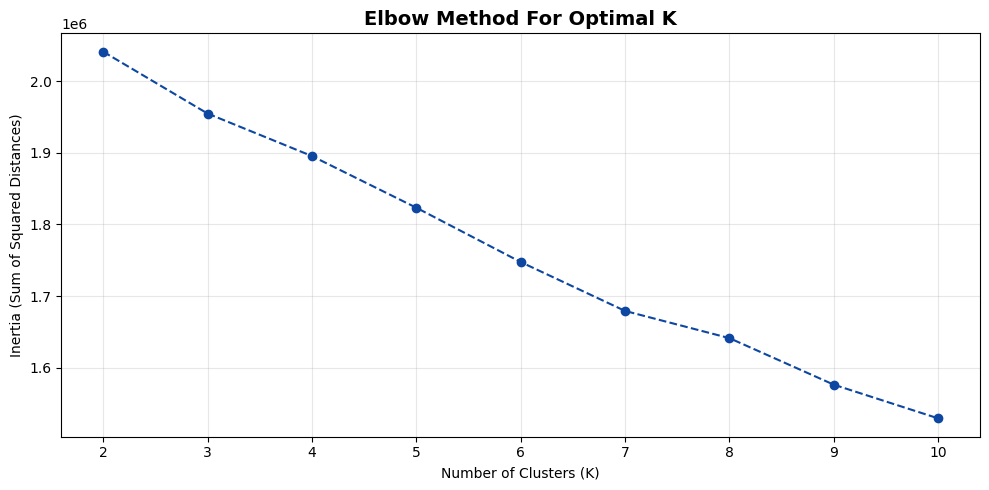

In [32]:
cluster_df = df_features.copy()
if 'loan_status' in cluster_df.columns:
    cluster_df = cluster_df.drop(columns=['loan_status'])

cat_cols = cluster_df.select_dtypes(include=['object']).columns
cluster_df = pd.get_dummies(cluster_df, columns=cat_cols, drop_first=True)

# 2. Scale the Features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)

# 3. Elbow Method to find optimal K
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='#0D47A1')
plt.title('Elbow Method For Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

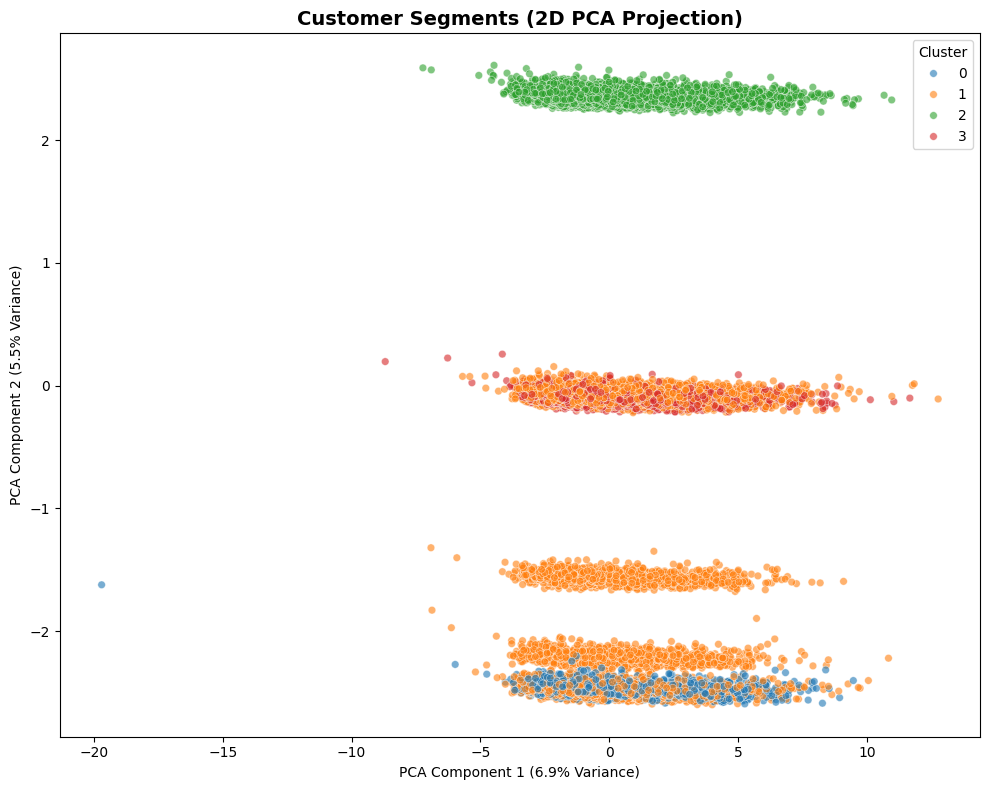

In [33]:
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_features)

df_features['Cluster'] = cluster_labels
cluster_df['Cluster'] = cluster_labels

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(data=pca_features, columns=['PCA_Component_1', 'PCA_Component_2'])
pca_df['Cluster'] = cluster_labels

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA_Component_1', 
    y='PCA_Component_2',
    hue='Cluster',
    palette='tab10',
    data=pca_df,
    alpha=0.6,
    s=30
)
plt.title('Customer Segments (2D PCA Projection)', fontsize=14, fontweight='bold')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [34]:
profiling_cols = [
    'person_income', 'loan_amnt', 'loan_int_rate', 
    'person_age', 'debt_to_income_ratio', 'vulnerable_borrower',
    'stability_index', 'est_monthly_payment'
]

if 'loan_status' in df_features.columns:
    profiling_cols.append('loan_status')

cluster_profile = df_features.groupby('Cluster')[profiling_cols].mean().round(3)
cluster_counts = df_features['Cluster'].value_counts().sort_index()
cluster_profile.insert(0, 'Customer_Count', cluster_counts)

print(cluster_profile.T)

Cluster                       0          1          2          3
Customer_Count         3608.000  14476.000  10944.000   3553.000
person_income         67014.594  65649.634  66305.939  66141.199
loan_amnt              9649.598   9566.329   9574.045   9669.301
loan_int_rate            10.965     11.029     10.993     11.069
person_age               27.705     27.762     27.730     27.514
debt_to_income_ratio      0.347      0.345      0.344      0.345
vulnerable_borrower       0.179      0.171      0.174      0.174
stability_index          30.632     29.973     30.350     28.573
est_monthly_payment     343.111    348.859    351.024    355.879
loan_status               0.222      0.218      0.217      0.219


In [35]:
TASK2_NEW_FEATURES = ["severe_default_history", "vulnerable_borrower", "monthly_payment_to_income"]

df_model = df.drop(columns=DROP_COLS, errors="ignore").copy()
for col in TASK2_NEW_FEATURES:
    df_model[col] = df_features[col].values

print("\nLog Transformation")

LOG_COLS = ['person_income', 'loan_amnt', 'other_debt']
for col in LOG_COLS:
    if col in df_model.columns:
        df_model[f'log_{col}'] = np.log1p(df_model[col])
        print(f"  log1p({col}) -> log_{col}")

print("\nOrdinal Encoding")

GRADE_MAP = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
EDUCATION_MAP = {'High School': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}

if 'loan_grade' in df_model.columns:
    df_model['loan_grade_enc'] = df_model['loan_grade'].map(GRADE_MAP)
    print(f"  loan_grade -> loan_grade_enc  {GRADE_MAP}")

if 'education_level' in df_model.columns:
    df_model['education_level_enc'] = df_model['education_level'].map(EDUCATION_MAP)
    print(f"  education_level -> education_level_enc  {EDUCATION_MAP}")

df_model = df_model.drop(columns=ORDINAL_VARS, errors='ignore')

print("\nBinary Encoding")

BINARY_MAP = {
    'cb_person_default_on_file': {'Y': 1, 'N': 0},
    'gender':                    {'Male': 1, 'Female': 0}
}
for col, mapping in BINARY_MAP.items():
    if col in df_model.columns:
        df_model[col] = df_model[col].map(mapping)
        print(f"  {col} -> {mapping}")

print("\nOne-Hot Encoding")

existing_nominal = [c for c in NOMINAL_VARS if c in df_model.columns]
df_model = pd.get_dummies(df_model, columns=existing_nominal, drop_first=True)
print(f"  Encoded: {existing_nominal}")
print(f"  Columns after encoding: {df_model.shape[1]}")

print("\nFeature Selection")

KEEP_NUM = (
    NUMERICAL_VARS
    + DERIVED_VARS
    + TASK2_NEW_FEATURES
    + [f"log_{c}" for c in LOG_COLS if c in df.columns]
)
KEEP_ENC = [c for c in df_model.columns if any(
    c.startswith(n) for n in NOMINAL_VARS
) or c in ['loan_grade_enc', 'education_level_enc'] + BINARY_VARS]
KEEP_ALL = [c for c in KEEP_NUM + KEEP_ENC if c in df_model.columns]

EXPORT_COLS = [c for c in KEEP_ALL + [TARGET] if c in df_model.columns]
df_model[EXPORT_COLS].to_csv("dataset_final_model_ready.csv", index=False)
print("Saved final model-ready matrix: dataset_final_model_ready.csv")

pd.DataFrame({"feature": KEEP_ALL}).to_csv("task2_final_feature_list.csv", index=False)
print("Saved: task2_final_feature_list.csv")

X = df_model[KEEP_ALL]
y = df_model[TARGET]

print(f"  Final feature count: {X.shape[1]}")
print(f"  Features: {list(X.columns)}")


Log Transformation
  log1p(person_income) -> log_person_income
  log1p(loan_amnt) -> log_loan_amnt
  log1p(other_debt) -> log_other_debt

Ordinal Encoding
  loan_grade -> loan_grade_enc  {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
  education_level -> education_level_enc  {'High School': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}

Binary Encoding
  cb_person_default_on_file -> {'Y': 1, 'N': 0}
  gender -> {'Male': 1, 'Female': 0}

One-Hot Encoding
  Encoded: ['person_home_ownership', 'loan_intent', 'marital_status', 'country', 'employment_type']
  Columns after encoding: 41

Feature Selection
Saved final model-ready matrix: dataset_final_model_ready.csv
Saved: task2_final_feature_list.csv
  Final feature count: 40
  Features: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'cb_person_cred_hist_length', 'loan_term_months', 'other_debt', 'open_accounts', 'past_delinquencies', 'loan_percent_income', 'loan_to_income_ratio', 'debt_to_income_rat

## Model constructing

In [36]:
X = df_features.drop(columns=['loan_status', 'Cluster'], errors='ignore')
y = df_features['loan_status']

# One-hot encode categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()

X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True
)

print(f"Feature matrix shape : {X.shape}")
print(f"Target shape         : {y.shape}")
print(f"Categorical columns  : {len(cat_cols)}")


Feature matrix shape : (32581, 66)
Target shape         : (32581,)
Categorical columns  : 9


In [37]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"Train set      : {X_train.shape}")
print(f"Validation set : {X_val.shape}")
print(f"Test set       : {X_test.shape}")

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(4))


Train set      : (19548, 66)
Validation set : (6516, 66)
Test set       : (6517, 66)

Train class distribution:
loan_status
0    0.7818
1    0.2182
Name: proportion, dtype: float64


In [38]:
# Numerical columns only
SCALE_COLS = X_train.select_dtypes(include=np.number).columns.tolist()

scaler = StandardScaler()

# Copy datasets
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

# Fit on train only
X_train_scaled[SCALE_COLS] = scaler.fit_transform(
    X_train[SCALE_COLS]
)

# Transform val/test
X_val_scaled[SCALE_COLS] = scaler.transform(
    X_val[SCALE_COLS]
)

X_test_scaled[SCALE_COLS] = scaler.transform(
    X_test[SCALE_COLS]
)

print(f"Scaled columns : {len(SCALE_COLS)}")

# Quick base vs enhanced logistic benchmark (same split, same scaler as above)
COMPARISON_FEATURES = ["severe_default_history", "vulnerable_borrower", "monthly_payment_to_income"]
drop_cols = [c for c in COMPARISON_FEATURES if c in X_train_scaled.columns]

lr_base = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
)
lr_full = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
)

X_train_base = X_train_scaled.drop(columns=drop_cols, errors="ignore")
X_val_base = X_val_scaled.drop(columns=drop_cols, errors="ignore")
X_test_base = X_test_scaled.drop(columns=drop_cols, errors="ignore")

lr_base.fit(X_train_base, y_train)
lr_full.fit(X_train_scaled, y_train)

benchmark = pd.DataFrame(
    {
        "variant": ["baseline (drop 3 engineered)", "enhanced (includes 3 engineered)"],
        "val_auc": [
            roc_auc_score(y_val, lr_base.predict_proba(X_val_base)[:, 1]),
            roc_auc_score(y_val, lr_full.predict_proba(X_val_scaled)[:, 1]),
        ],
        "test_auc": [
            roc_auc_score(y_test, lr_base.predict_proba(X_test_base)[:, 1]),
            roc_auc_score(y_test, lr_full.predict_proba(X_test_scaled)[:, 1]),
        ],
    }
)
display(benchmark)
benchmark.to_csv("task2_logreg_base_vs_enhanced_auc.csv", index=False)
print("Saved: task2_logreg_base_vs_enhanced_auc.csv")

Scaled columns : 21


,variant,val_auc,test_auc
0,baseline (drop 3 engineered),0.873896,0.878977
1,enhanced (includes 3 engineered),0.876351,0.881113


Saved: task2_logreg_base_vs_enhanced_auc.csv


In [39]:
models = {
    'Logistic Regression': (
        LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ),
        True  # use scaled data
    ),

    'Random Forest': (
        RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ),
        False
    ),

    'Gradient Boosting': (
        GradientBoostingClassifier(
            n_estimators=200,
            random_state=42
        ),
        False
    )
}

def get_metrics(y_true, y_pred, y_proba):

    return {
        'Accuracy': accuracy_score(y_true, y_pred),

        'Precision': precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        'Recall': recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        'F1': f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        'AUC': roc_auc_score(
            y_true,
            y_proba
        )
    }


results = {}

for name, (model, use_scaled) in models.items():

    print(f"\nTraining: {name}")

    # Choose scaled or unscaled data
    Xtr = X_train_scaled if use_scaled else X_train
    Xv  = X_val_scaled   if use_scaled else X_val
    Xte = X_test_scaled  if use_scaled else X_test

    # Fit model
    model.fit(Xtr, y_train)

    # Predictions
    y_pred_train = model.predict(Xtr)
    y_pred_val   = model.predict(Xv)
    y_pred_test  = model.predict(Xte)

    # Probabilities
    y_proba_train = model.predict_proba(Xtr)[:, 1]
    y_proba_val   = model.predict_proba(Xv)[:, 1]
    y_proba_test  = model.predict_proba(Xte)[:, 1]

    # Store results
    results[name] = {
        'model': model,

        'train': get_metrics(
            y_train,
            y_pred_train,
            y_proba_train
        ),

        'val': get_metrics(
            y_val,
            y_pred_val,
            y_proba_val
        ),

        'test': get_metrics(
            y_test,
            y_pred_test,
            y_proba_test
        ),

        'y_pred_val': y_pred_val,
        'y_proba_val': y_proba_val,

        'y_pred_test': y_pred_test,
        'y_proba_test': y_proba_test
    }


Training: Logistic Regression

Training: Random Forest

Training: Gradient Boosting


In [40]:
for name in models:

    print(f"\n{name}")

    print(f"{'Metric':<12} {'Train':>10} {'Val':>10} {'Test':>10}")
    print("-" * 46)

    for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']:

        tr = results[name]['train'][metric]
        vl = results[name]['val'][metric]
        te = results[name]['test'][metric]

        print(f"{metric:<12} {tr:>10.4f} {vl:>10.4f} {te:>10.4f}")


Logistic Regression
Metric            Train        Val       Test
----------------------------------------------
Accuracy         0.8020     0.8017     0.8042
Precision        0.5314     0.5306     0.5345
Recall           0.7822     0.7861     0.7961
F1               0.6328     0.6336     0.6395
AUC              0.8725     0.8764     0.8811

Random Forest
Metric            Train        Val       Test
----------------------------------------------
Accuracy         1.0000     0.9253     0.9273
Precision        1.0000     0.9633     0.9611
Recall           1.0000     0.6833     0.6948
F1               1.0000     0.7995     0.8065
AUC              1.0000     0.9226     0.9207

Gradient Boosting
Metric            Train        Val       Test
----------------------------------------------
Accuracy         0.9343     0.9285     0.9271
Precision        0.9593     0.9393     0.9239
Recall           0.7299     0.7185     0.7257
F1               0.8290     0.8142     0.8129
AUC              0.948

In [41]:
BLUE, RED, NAVY = '#2196F3', '#EF5350', '#0D47A1'
model_names  = list(models.keys())
color_models = [BLUE, '#4CAF50', '#FF9800']

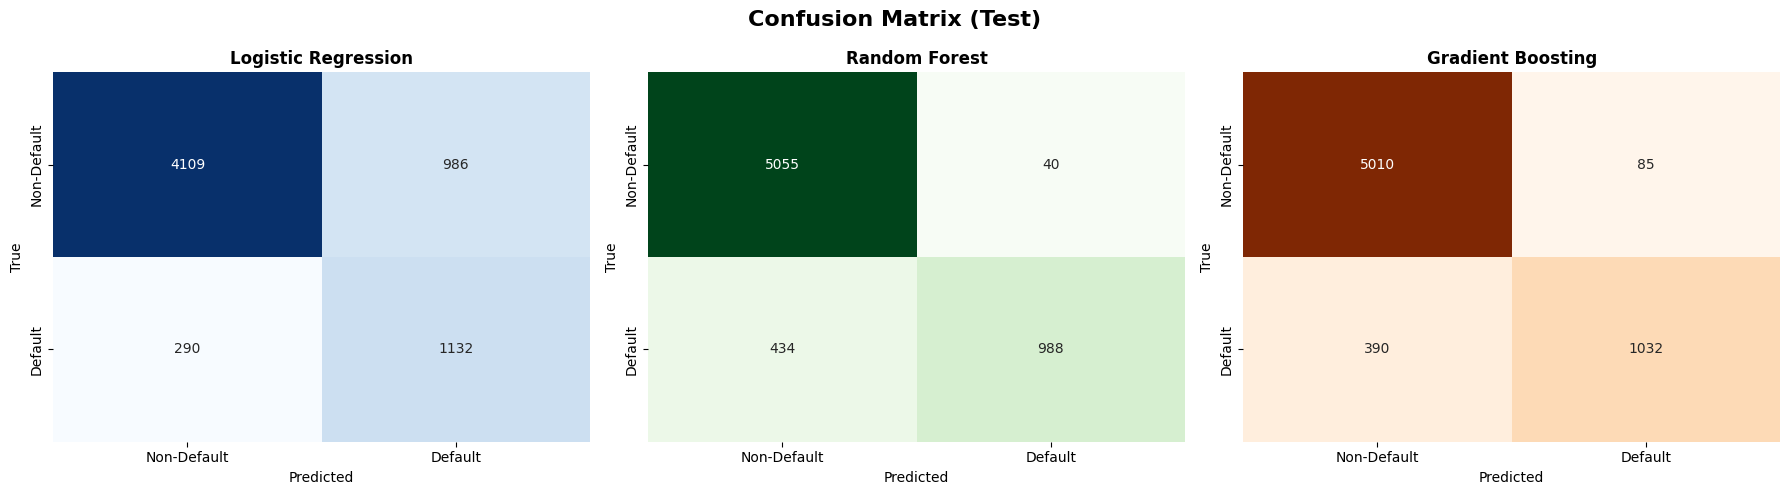

In [42]:
fig, axes = plt.subplots(1, len(model_names), figsize=(18, 5))
fig.suptitle('Confusion Matrix (Test)', fontsize=16, fontweight='bold')

for idx, name in enumerate(model_names):
    ax = axes[idx] if len(model_names) > 1 else axes
    cm = confusion_matrix(y_test, results[name]['y_pred_test'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=['Blues','Greens','Oranges'][idx],
                ax=ax, cbar=False,
                xticklabels=['Non-Default', 'Default'],
                yticklabels=['Non-Default', 'Default'])
    ax.set_title(f'{name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.show()

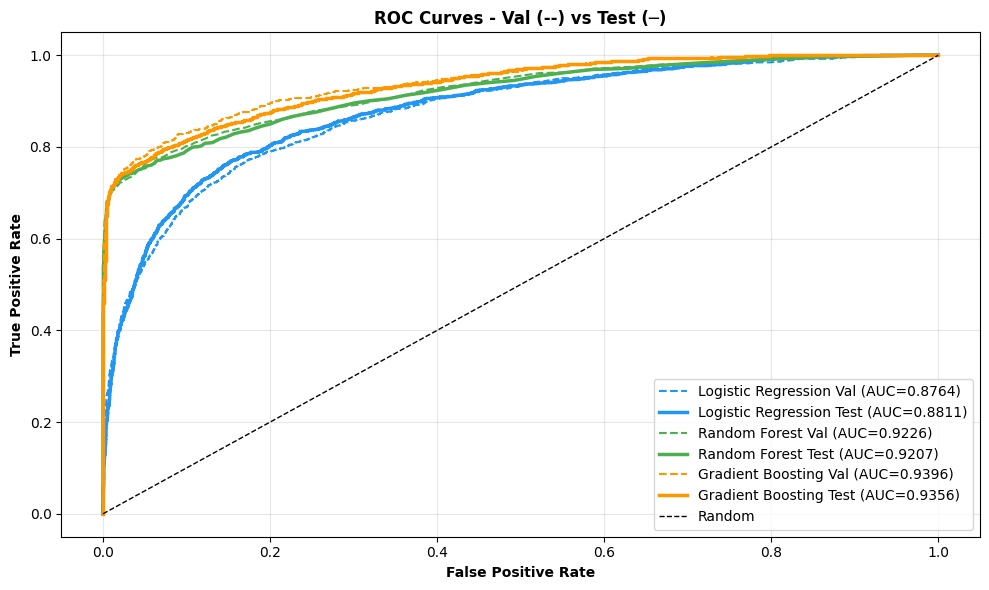

In [43]:
plt.figure(figsize=(10, 6))

for idx, name in enumerate(model_names):
    fpr_v, tpr_v, _ = roc_curve(y_val,  results[name]['y_proba_val'])
    fpr_t, tpr_t, _ = roc_curve(y_test, results[name]['y_proba_test'])
    auc_v = results[name]['val']['AUC']
    auc_t = results[name]['test']['AUC']
    
    plt.plot(fpr_v, tpr_v, lw=1.5, color=color_models[idx], linestyle='--',
             label=f'{name} Val (AUC={auc_v:.4f})')
    plt.plot(fpr_t, tpr_t, lw=2.5, color=color_models[idx],
             label=f'{name} Test (AUC={auc_t:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('ROC Curves - Val (--) vs Test (─)', fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

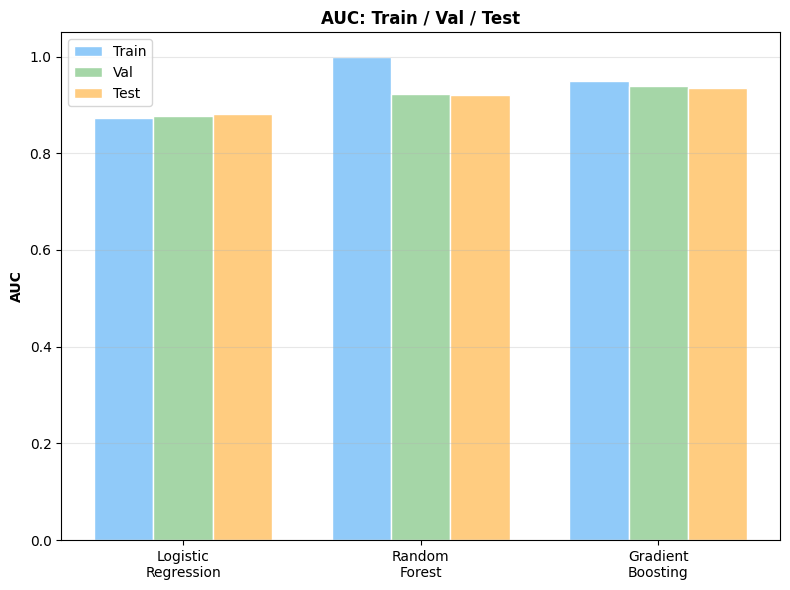

In [44]:
plt.figure(figsize=(8, 6))
x_pos = np.arange(len(model_names))
width = 0.25

for i, split in enumerate(['train', 'val', 'test']):
    vals = [results[n][split]['AUC'] for n in model_names]
    plt.bar(x_pos + i*width, vals, width,
            label=split.capitalize(), color=['#90CAF9','#A5D6A7','#FFCC80'][i], edgecolor='white')

plt.xticks(x_pos + width, [n.replace(' ', '\n') for n in model_names], fontsize=10)
plt.ylabel('AUC', fontweight='bold')
plt.title('AUC: Train / Val / Test', fontweight='bold')
plt.ylim([0, 1.05])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

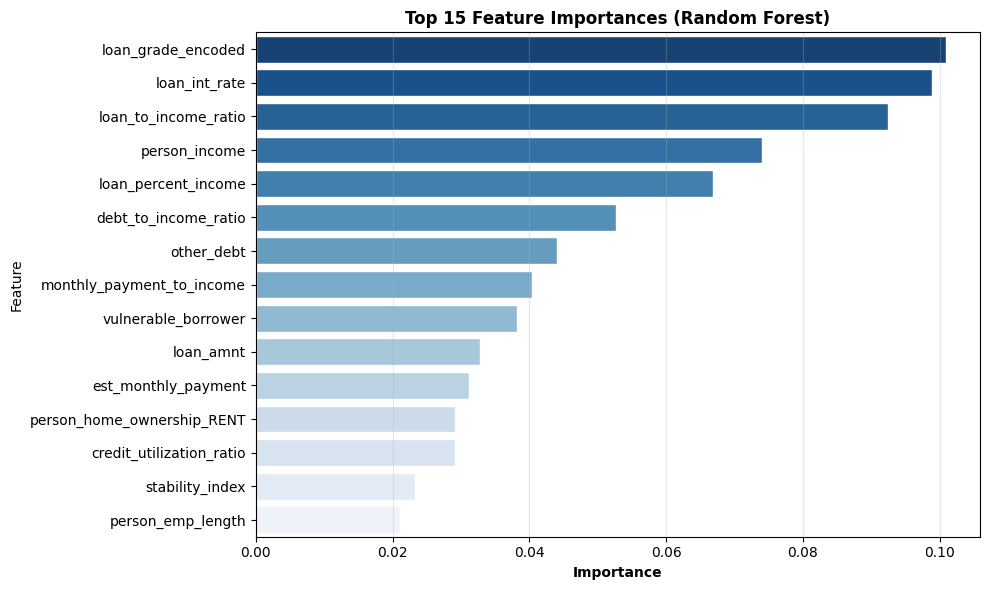

In [45]:
plt.figure(figsize=(10, 6))
rf_model = results['Random Forest']['model']
feat_imp = pd.DataFrame({
    'Feature': X.columns, 'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

sns.barplot(data=feat_imp, y='Feature', x='Importance', palette='Blues_r', edgecolor='white')
plt.xlabel('Importance', fontweight='bold')
plt.title('Top 15 Feature Importances (Random Forest)', fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

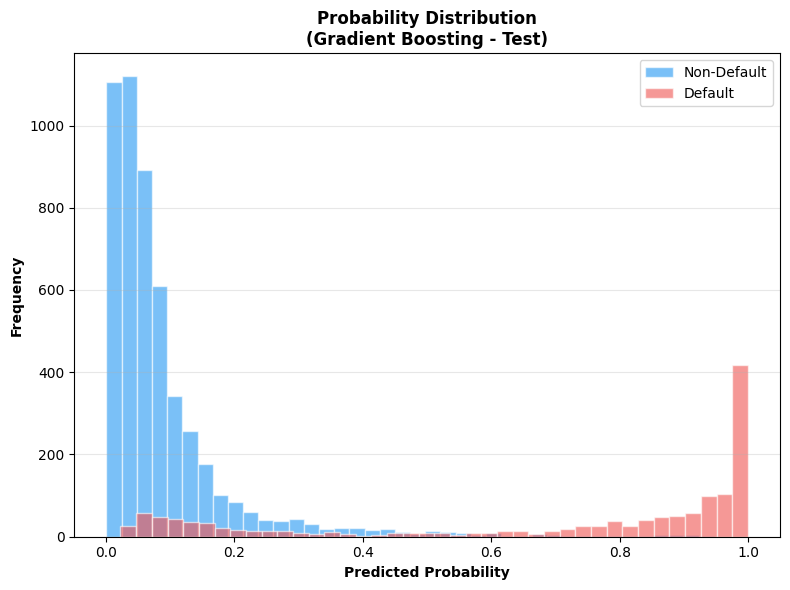

In [46]:
plt.figure(figsize=(8, 6))
best_name = max(results, key=lambda n: results[n]['test']['AUC'])

plt.hist(results[best_name]['y_proba_test'][y_test == 0], bins=40, alpha=0.6,
         color=BLUE, label='Non-Default', edgecolor='white')
plt.hist(results[best_name]['y_proba_test'][y_test == 1], bins=40, alpha=0.6,
         color=RED, label='Default', edgecolor='white')

plt.xlabel('Predicted Probability', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title(f'Probability Distribution\n({best_name} - Test)', fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
print("\nModel Comparison Summary (Test Set):")
summary = pd.DataFrame({
    n: results[n]['test'] for n in model_names
}).T
print(summary.round(4))
best_name = max(results, key=lambda n: results[n]['test']['AUC'])
print(f"\nBest Model: {best_name}  (AUC: {results[best_name]['test']['AUC']:.4f})")


Model Comparison Summary (Test Set):
                     Accuracy  Precision  Recall      F1     AUC
Logistic Regression    0.8042     0.5345  0.7961  0.6395  0.8811
Random Forest          0.9273     0.9611  0.6948  0.8065  0.9207
Gradient Boosting      0.9271     0.9239  0.7257  0.8129  0.9356

Best Model: Gradient Boosting  (AUC: 0.9356)


In [48]:
summary.to_csv(
    "model_comparison_summary.csv",
    index=True,
)
summary.to_csv(
    "task2_preliminary_model_benchmark.csv",
    index=True,
)

print("\nSaved: model_comparison_summary.csv")
print("Saved: task2_preliminary_model_benchmark.csv (duplicate for Task 2 reporting)")


Saved: model_comparison_summary.csv
Saved: task2_preliminary_model_benchmark.csv (duplicate for Task 2 reporting)


## FINAL CHECK

In [49]:
qc_path = "dataset_final_model_ready.csv"
qc = pd.read_csv(qc_path)

THREE_QC = ["severe_default_history", "vulnerable_borrower", "monthly_payment_to_income"]

report = {
    "file": qc_path,
    "n_rows": len(qc),
    "n_columns": qc.shape[1],
    "missing_cells_total": int(qc.isna().sum().sum()),
    "duplicate_rows": int(qc.duplicated().sum()),
    "has_target_loan_status": TARGET in qc.columns,
    "has_all_three_new_features": all(c in qc.columns for c in THREE_QC),
}

display(pd.DataFrame([report]))

task2_checklist = pd.DataFrame(
    [
        ("1", "Variable classification table", "task2_variable_classification.csv"),
        ("2", "Encoding / transformation strategy table", "task2_encoding_strategy.csv"),
        ("3", "Predictive relevance (corr, DR tables, LR AUC base vs enhanced)",
         "task2_new_feature_correlations.csv; task2_default_rate_severe_x_vulnerable.csv; task2_default_rate_mpti_quartiles.csv; task2_logreg_base_vs_enhanced_auc.csv"),
        ("4", "Final model-ready export", "dataset_final_model_ready.csv"),
        ("5", "Preliminary models labelled", "Markdown trước cell training"),
        ("6", "Final quality check", "task2_final_quality_check.csv"),
    ],
    columns=["Item", "Deliverable", "Artifact(s)"],
)
display(task2_checklist)

pd.DataFrame([report]).to_csv("task2_final_quality_check.csv", index=False)
task2_checklist.to_csv("task2_submission_checklist.csv", index=False)
print("Saved: task2_final_quality_check.csv, task2_submission_checklist.csv")

,file,n_rows,n_columns,missing_cells_total,duplicate_rows,has_target_loan_status,has_all_three_new_features
0,dataset_final_model_ready.csv,32581,41,0,0,True,True


,Item,Deliverable,Artifact(s)
0,1,Variable classification table,task2_variable_classification.csv
1,2,Encoding / transformation strategy table,task2_encoding_strategy.csv
2,3,"Predictive relevance (corr, DR tables, LR AUC ...",task2_new_feature_correlations.csv; task2_defa...
3,4,Final model-ready export,dataset_final_model_ready.csv
4,5,Preliminary models labelled,Markdown trước cell training
5,6,Final quality check,task2_final_quality_check.csv


Saved: task2_final_quality_check.csv, task2_submission_checklist.csv
